<a href="https://colab.research.google.com/github/Terry4715/MVO-backtest/blob/main/codeAlong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import os
import sys
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive/')

# Define the path to directory
data_path = '/content/drive/MyDrive/ColabNotebooks/EDHEC_Learning'

# Add the directory to sys.path to allow Python to find custom module
if data_path not in sys.path:
    sys.path.append(data_path)

# Import your custom module
import toolkit as tk


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


1935-01    0.0114
1935-02   -0.1274
1935-03   -0.0897
1935-04    0.0796
1935-05   -0.0025
            ...  
2018-08    0.0241
2018-09   -0.0168
2018-10   -0.1002
2018-11   -0.0365
2018-12   -0.1531
Freq: M, Name: SmallCap, Length: 1008, dtype: float64


<Axes: >

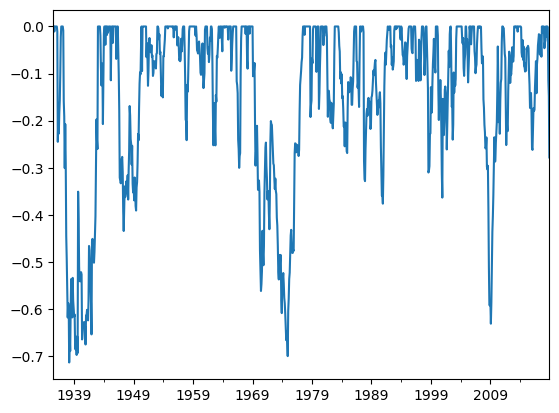

In [4]:
# 5. Use the get_returns function from your module
returns_data = tk.get_ls_returns()
print(returns_data['1935':]['SmallCap'])

dd = tk.drawdown(returns_data['1935-07':]['SmallCap'])['Drawdown']
dd.plot()



# Deviations from Normality

In [5]:
hfi = tk.get_hf_returns()
hfi["2000":]["CTA Global"].head()

hf_skewness = pd.concat([hfi.mean(), hfi.median(), hfi.mean() > hfi.median()], axis='columns', keys=['Mean', 'Median', 'Negative Skew'])
hf_skewness

/content/drive/MyDrive/ColabNotebooks/EDHEC_Learning/toolkit.py:53: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv(file_path, header=0, index_col=0, parse_dates=True)


,Mean,Median,Negative Skew
Convertible Arbitrage,0.005508,0.0065,False
CTA Global,0.004074,0.0014,True
Distressed Securities,0.006946,0.0089,False
Emerging Markets,0.006253,0.0096,False
Equity Market Neutral,0.004498,0.0051,False
Event Driven,0.006344,0.0084,False
Fixed Income Arbitrage,0.004365,0.0055,False
Global Macro,0.005403,0.0038,True
Long/Short Equity,0.006331,0.0079,False
Merger Arbitrage,0.005356,0.0060,False


# Skewness
$$ S(R) = \frac{E (R-E(R))^3]}{\sigma_R^3} $$

In [18]:
def skewness(r):
  '''
  Alt script to scipy.skew()
  Computes the skewness of the supplied Series or DataFrame
  Returns a float or a Series
  '''

  demeaned_r = r - r.mean()
  # use the population std by setting dof=0
  sigma_r = r.std(ddof=0)
  exp = (demeaned_r**3).mean()
  return exp/sigma_r**3

skewness(hfi)

,0
Convertible Arbitrage,-2.639592
CTA Global,0.173699
Distressed Securities,-1.300842
Emerging Markets,-1.167067
Equity Market Neutral,-2.124435
Event Driven,-1.409154
Fixed Income Arbitrage,-3.940320
Global Macro,0.982922
Long/Short Equity,-0.390227
Merger Arbitrage,-1.320083


In [17]:
import scipy.stats

scipy.stats.skew(hfi)


array([-2.63959223,  0.17369864, -1.30084204, -1.16706749, -2.12443538,
       -1.40915356, -3.94032029,  0.98292188, -0.39022677, -1.32008333,
       -1.81546975,  0.76797484, -0.36178308])

# Kurtosis
$$ K(R) = \frac{E[ (R-E(R))^4 ]}{\sigma_R^4} $$

In [61]:
def kertosis(r):
  '''
  Alt script to scipy.kertosis()
  Computes the kertosis of the supplied Series or DataFrame
  Returns a float or a Series
  '''

  demeaned_r = r - r.mean()
  # use the population std by setting dof=0
  sigma_r = r.std(ddof=0)
  exp = (demeaned_r**4).mean()
  return exp/sigma_r**4

print(kertosis(hfi))

scipy.stats.kurtosis(hfi)


Convertible Arbitrage     23.280834
CTA Global                 2.952960
Distressed Securities      7.889983
Emerging Markets           9.250788
Equity Market Neutral     17.218555
Event Driven               8.035828
Fixed Income Arbitrage    29.842199
Global Macro               5.741679
Long/Short Equity          4.523893
Merger Arbitrage           8.738950
Relative Value            12.121208
Short Selling              6.117772
Funds Of Funds             7.070153
dtype: float64


array([20.28083446, -0.04703963,  4.88998336,  6.25078841, 14.21855526,
        5.03582817, 26.84219928,  2.74167945,  1.52389258,  5.73894979,
        9.12120787,  3.11777175,  4.07015278])

In [73]:
def is_normal(r, level=0.01):
  '''
  Applies the Jarque-Bera test to determine if a Series is normal or not
  Test is applied at the 1% level by default
  Returns True if the hypothesis of normality is accepted, False otherwise
  '''
  statistic, p_value = scipy.stats.jarque_bera(r)
  return p_value > level

a = hfi.aggregate(is_normal)
print(a)

Convertible Arbitrage     False
CTA Global                 True
Distressed Securities     False
Emerging Markets          False
Equity Market Neutral     False
Event Driven              False
Fixed Income Arbitrage    False
Global Macro              False
Long/Short Equity         False
Merger Arbitrage          False
Relative Value            False
Short Selling             False
Funds Of Funds            False
dtype: bool


,0
SmallCap,False
LargeCap,False
